## Phase 2: Dataset acquisition & preprocessing 

In [2]:
import wfdb
import os
import numpy as np
import matplotlib.pyplot as plt
from wfdb import processing, io, plot
from scipy.signal import butter, filtfilt
from collections import Counter

### Download full MIT-BIH dataset

#### The MIT-BIH database contains 48 half-hour two-channel ECG recordings sampled at 360 Hz. Each record has three files:
##### • .hea — header: metadata (sampling rate, lead names, number of samples)
##### • .dat — raw signal (binary)
##### • .atr — annotation file (beat labels and positions)

##### The wfdb library handles all three automatically.

In [2]:
# Download all 48 MIT-BIH records
wfdb.dl_database('mitdb', dl_dir='./mitdb_data')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [3]:
# Verify download
records = [f.replace('.hea','') for f in os.listdir('./mitdb_data') if f.endswith('.hea')]
print(f"Records downloaded: {len(records)}")
print("First 10:", sorted(records)[:10])

Records downloaded: 48
First 10: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']


In [4]:
# Quick sanity check on one record
record = wfdb.rdrecord('./mitdb_data/100')
print(f"Sampling frequency: {record.fs} Hz")
print(f"Signal shape: {record.p_signal.shape}")
print(f"Lead names: {record.sig_name}")

Sampling frequency: 360 Hz
Signal shape: (650000, 2)
Lead names: ['MLII', 'V5']


### Zero-phase Butterworth bandpass filter

#### Raw ECG has three main noise sources:
##### • Baseline wander (<0.5 Hz) — slow drift from breathing and electrode movement
##### • Powerline interference (~50/60 Hz) — electrical noise from the environment
##### • Muscle artefacts (>40 Hz) — EMG noise from patient movement

#### A Butterworth filter has a maximally flat passband — it doesn't distort the signal frequencies you want to keep.

#### Zero-phase filtering (filtfilt): applies the filter TWICE for forward and backward. This cancels any time-shift (phase distortion), keeping R-peaks at their correct positions. Critical because Pan-Tompkins needs accurate peak timing.

In [5]:
#bandpass filtering function
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=360, order=4):
    nyq = 0.5 * fs          # Nyquist frequency = 180 Hz
    low = lowcut / nyq      # Normalised lower cutoff
    high = highcut / nyq    # Normalised upper cutoff
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)  # Zero-phase: no time shift

In [6]:
# Load record 100
record = wfdb.rdrecord('./mitdb_data/100')
fs = record.fs
raw_signal = record.p_signal[:, 0]  # MLII lead

In [7]:
# Apply filter
filtered_signal = bandpass_filter(raw_signal, fs=fs)

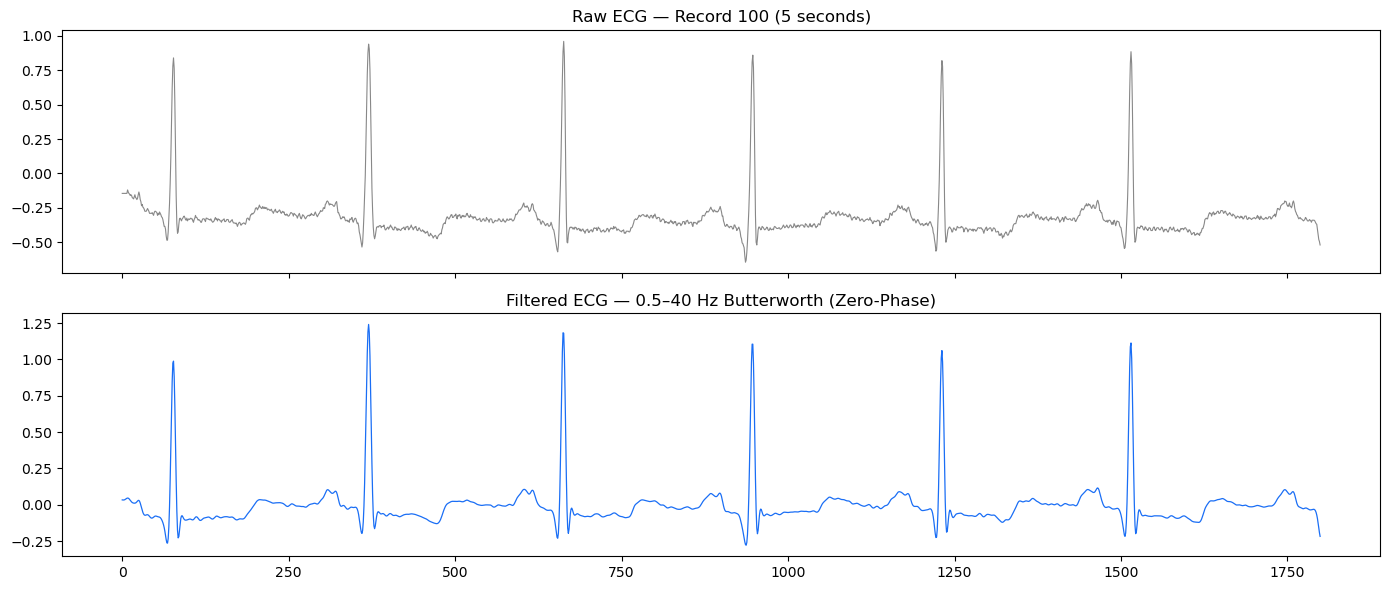

In [8]:
# Plot: evidence for supervisor
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(raw_signal[:1800], color='#888', linewidth=0.8)
axes[0].set_title('Raw ECG — Record 100 (5 seconds)')
axes[1].plot(filtered_signal[:1800], color='#1a6ef5', linewidth=0.9)
axes[1].set_title('Filtered ECG — 0.5–40 Hz Butterworth (Zero-Phase)')
plt.tight_layout()
plt.savefig('filtering_comparison.png', dpi=150)
plt.show()

### R-peak detection via GQRS (WFDB)

#### The Pan-Tompkins algorithm (1985) is the gold-standard real-time QRS detector. It works in 5 steps:
##### 1. Bandpass filter — already done above
##### 2. Differentiate — emphasises the steep QRS slope
##### 3. Square — makes all values positive, amplifies large slopes
##### 4. Moving-window integration — smooths into a hump around each QRS
##### 5. Adaptive thresholding — detects peaks above a dynamic threshold
#### But I used GQRS instead of Pan-Tompkins alogrithm (1985)
#### The wfdb library's gqrs_detect() implements this. You get back an array of sample indices where R-peaks occur.
#### GQRS is the open-source QRS detector bundled with the WFDB software package. It applies bandpass filtering followed by adaptive-threshold peak detection to locate R-peaks in real time. Here it is used only to validate detection quality against the expert reference annotations (reported below as sensitivity and positive predictivity on record 100). For the classification pipeline itself, beats are segmented around the **expert reference R-peak annotations** (`annotation.sample`), not the detected peaks, so that every beat window is perfectly aligned with its ground-truth label. This follows the inter-patient practice of de Chazal et al. (2004).

In [51]:
# Load record and annotations
record = wfdb.rdrecord('./mitdb_data/100')
annotation = wfdb.rdann('./mitdb_data/100', 'atr')
signal = record.p_signal[:, 0]
fs = record.fs

In [52]:
# GQRS R-peak detection (WFDB) — illustration on record 100
qrs_inds = processing.gqrs_detect(sig=signal, fs=fs)

print(f"R-peaks detected: {len(qrs_inds)}")
print(f"Expert annotations: {len(annotation.sample)}")
print(f"First 5 detected:  {qrs_inds[:5]}")
print(f"First 5 annotated: {annotation.sample[:5]}")

R-peaks detected: 2272
Expert annotations: 2274
First 5 detected:  [ 357  650  934 1219 1502]
First 5 annotated: [ 18  77 370 662 946]


In [53]:
# Reference = actual beat annotations only (exclude non-beat markers like +, ~, |),
# using the AAMI_MAP you already defined so it's consistent with the pipeline.
is_beat   = np.array([AAMI_MAP.get(s) is not None for s in annotation.symbol])
ref_beats = annotation.sample[is_beat]

cmp = compare_annotations(ref_sample=ref_beats, test_sample=qrs_inds,
                          window_width=int(0.05 * fs), signal=signal)
cmp.print_summary()
print(f"\nSensitivity: {cmp.sensitivity:.4f} | PPV: {cmp.positive_predictivity:.4f}")
print(f"Ref beats: {len(ref_beats)} | Detected: {len(qrs_inds)} | "
      f"TP={cmp.tp} FP={cmp.fp} FN={cmp.fn}")

2273 reference annotations, 2272 test annotations

True Positives (matched samples): 2272
False Positives (unmatched test samples): 0
False Negatives (unmatched reference samples): 1

Sensitivity: 0.9996 (2272/2273)
Positive Predictivity: 1.0000 (2272/2272)

Sensitivity: 0.9996 | PPV: 1.0000
Ref beats: 2273 | Detected: 2272 | TP=2272 FP=0 FN=1


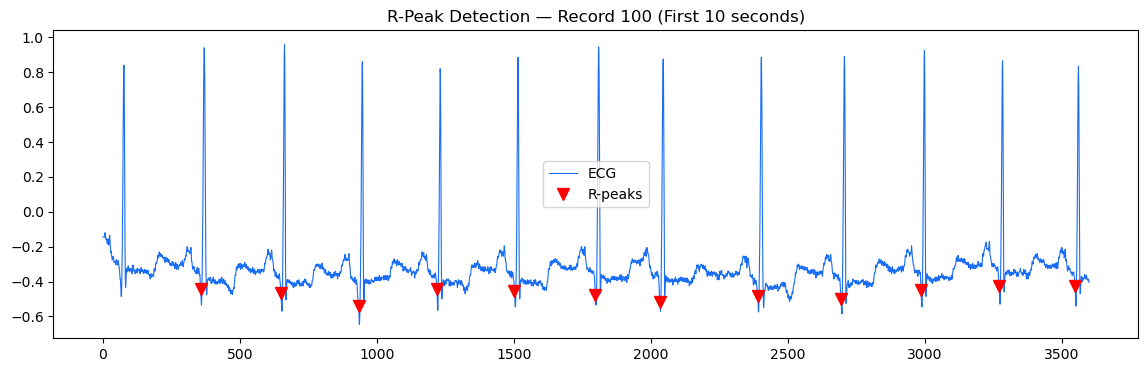

In [12]:
# Visualise
plt.figure(figsize=(14, 4))
plt.plot(signal[:3600], color='#1a6ef5', linewidth=0.8, label='ECG')
peaks_in_window = qrs_inds[qrs_inds < 3600]
plt.plot(peaks_in_window, signal[peaks_in_window], 'rv', markersize=8, label='R-peaks')
plt.title('R-Peak Detection — Record 100 (First 10 seconds)')
plt.legend()
plt.savefig('rpeak_detection.png', dpi=150)
plt.show()

### AAMI EC57 beat label mapping

#### AAMI EC57 defines 5 clinically meaningful classes:
##### • N — Normal beats (also L, R, e, j) — most common, ~75%
##### • S — Supraventricular ectopic (A, a, J, S) — originate above ventricles
##### • V — Ventricular ectopic (V, E) — originate in ventricles; clinically important
##### • F — Fusion beats (F) — part normal, part ventricular
##### • Q — Unknown/paced beats (/, f, Q) — unclassifiable or pacemaker-generated

In [13]:
# AAMI EC57 mapping
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q'
}


In [14]:
# Process all 48 records
records = [f.replace('.hea','') for f in os.listdir('./mitdb_data') if f.endswith('.hea')]
all_labels = []

for rec in sorted(records):
    try:
        ann = wfdb.rdann(f'./mitdb_data/{rec}', 'atr')
        mapped = [AAMI_MAP.get(sym) for sym in ann.symbol]
        all_labels.extend([l for l in mapped if l is not None])
    except:
        pass


In [43]:
# Class distribution at the ANNOTATION level (before beat segmentation)
counts = Counter(all_labels)
total = sum(counts.values())
print("AAMI Class Distribution — annotation level, pre-segmentation:")
print("-" * 52)
for cls in ['N', 'S', 'V', 'F', 'Q']:
    n = counts.get(cls, 0)
    print(f"  {cls}: {n:>6,} beats  ({100*n/total:.1f}%)")
print(f"  TOTAL: {total:,} annotations")
print("\nNote: the study uses 109,454 SEGMENTED beats (see next figure);")
print("the ~40-beat gap is edge beats dropped during segmentation.")

AAMI Class Distribution — annotation level, pre-segmentation:
----------------------------------------------------
  N: 90,631 beats  (82.8%)
  S:  2,781 beats  (2.5%)
  V:  7,236 beats  (6.6%)
  F:    803 beats  (0.7%)
  Q:  8,043 beats  (7.3%)
  TOTAL: 109,494 annotations

Note: the study uses 109,454 SEGMENTED beats (see next figure);
the ~40-beat gap is edge beats dropped during segmentation.


## Phase 3: Feature Engineering & Formatting

### Beat Segmentation Around R-Peaks

#### Window: 250 ms before the R-peak, 400 ms after it.At 360 Hz that's 90 samples before, 144 after that 234 samples per beat.

#### Keep this window IDENTICAL across MLP, 1D-CNN, and LSTM so their inputs are directly comparable. Beats too close to the start/end of a recording (incomplete windows) are skipped.

In [19]:
def segment_beats(signal, r_peaks, labels, fs=360, pre_ms=250, post_ms=400):
    pre = int(pre_ms / 1000 * fs)
    post = int(post_ms / 1000 * fs)
    beats, beat_labels = [], []
    for peak, label in zip(r_peaks, labels):
        if label is None:
            continue                            # skip non-beat annotations (+, ~, |, x, etc.)
        start, end = peak - pre, peak + post
        if start < 0 or end > len(signal):
            continue                            # skip incomplete beats at signal edges
        beats.append(signal[start:end])
        beat_labels.append(label)
    return np.array(beats), np.array(beat_labels)

### Scale Preprocessing to All 48 Records

In [20]:
# Loop preprocessing across all 48 records — fixes the record-100-only limitation
all_beats = []
all_beat_labels = []
all_patient_ids = []

for rec in sorted(records):
    try:
        record = wfdb.rdrecord(f'./mitdb_data/{rec}')
        annotation = wfdb.rdann(f'./mitdb_data/{rec}', 'atr')
        signal = record.p_signal[:, 0]
        fs = record.fs

        # Filter 
        filtered = bandpass_filter(signal, fs=fs)

        # AAMI labels for this record 
        rec_labels = [AAMI_MAP.get(sym) for sym in annotation.symbol]

        # Segment beats 
        beats, beat_labels = segment_beats(filtered, annotation.sample, rec_labels)

        all_beats.append(beats)
        all_beat_labels.append(beat_labels)
        all_patient_ids.extend([rec] * len(beats))  # tag every beat with its source record
    except Exception as e:
        print(f"Skipped {rec}: {e}")

beats = np.concatenate(all_beats)
beat_labels = np.concatenate(all_beat_labels)
patient_ids = np.array(all_patient_ids)

print(f"Total beats across all records: {len(beats)}")
print(f"Total unique patients: {len(set(patient_ids))}")
print(f"Beat shape: {beats[0].shape}")

Total beats across all records: 109454
Total unique patients: 48
Beat shape: (234,)


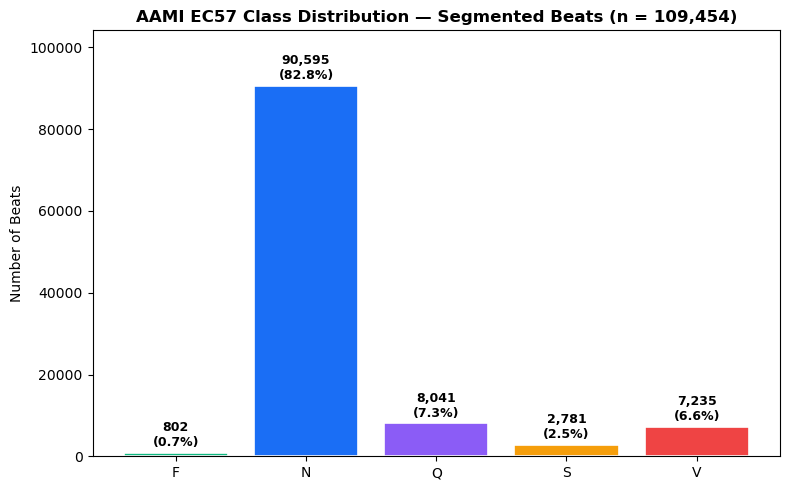

Total segmented beats: 109,454
  F:     802 (0.7%)
  N:  90,595 (82.8%)
  Q:   8,041 (7.3%)
  S:   2,781 (2.5%)
  V:   7,235 (6.6%)


In [40]:
# AAMI EC57 class distribution — computed from the ACTUAL segmented beats
from collections import Counter

counts_map = Counter(str(l) for l in beat_labels)     # real counts, not textbook values
classes = sorted(counts_map)                          # ['F','N','Q','S','V'] — alphabetical
counts  = [counts_map[c] for c in classes]
total   = sum(counts)

# Fixed colour per class so the mapping is stable regardless of order
color_map = {'F': '#10b981', 'N': '#1a6ef5', 'Q': '#8b5cf6', 'S': '#f59e0b', 'V': '#ef4444'}
colors = [color_map[c] for c in classes]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(classes, counts, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title(f'AAMI EC57 Class Distribution — Segmented Beats (n = {total:,})',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Beats')

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total * 0.008,
            f'{val:,}\n({100*val/total:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"Total segmented beats: {total:,}")
for c, v in zip(classes, counts):
    print(f"  {c}: {v:>7,} ({100*v/total:.1f}%)")

### Build patient_ids and the GroupKFold Split

#### GroupKFold splits by GROUP (patient/record ID), not by individual beat. Every beat from one patient stays entirely in either train or test — never split across both.

In [22]:
from sklearn.model_selection import GroupKFold

# Now patient_ids exists and is aligned with beats/beat_labels from Task 1
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(beats, beat_labels, groups=patient_ids))

train_idx, test_idx = folds[0]
X_train, X_test = beats[train_idx], beats[test_idx]
y_train, y_test = beat_labels[train_idx], beat_labels[test_idx]

train_patients = set(patient_ids[train_idx])
test_patients = set(patient_ids[test_idx])
print(f"Train patients: {len(train_patients)} | Test patients: {len(test_patients)}")
print(f"Overlap (should be 0): {len(train_patients & test_patients)}")

Train patients: 39 | Test patients: 9
Overlap (should be 0): 0


### Three-Domain Feature Extraction

#### Three feature domains, one feature vector per beat:

##### 1. Time-domain — mean, std, skewness, kurtosis, RMS. Basic statistical shape of the beat.
##### 2. Frequency-domain — FFT-based dominant frequency and spectral energy. Rhythm characteristics.
##### 3. Wavelet-domain — db4 wavelet decomposition (level 4), energy per sub-band. Captures localised time-frequency changes that pure FFT averages away.

In [23]:
from scipy.stats import skew, kurtosis
import pywt
import pandas as pd

def extract_features(beat, fs=360):
    feats = {}
    # 1. Time-domain
    feats['mean'] = np.mean(beat)
    feats['std'] = np.std(beat)
    feats['skew'] = skew(beat)
    feats['kurtosis'] = kurtosis(beat)
    feats['rms'] = np.sqrt(np.mean(beat**2))

    # 2. Frequency-domain
    fft_vals = np.abs(np.fft.rfft(beat))
    feats['dominant_freq'] = np.argmax(fft_vals)
    feats['spectral_energy'] = np.sum(fft_vals**2)

    # 3. Wavelet-domain (db4, level 4)
    coeffs = pywt.wavedec(beat, 'db4', level=4)
    for i, c in enumerate(coeffs):
        feats[f'wavelet_energy_L{i}'] = np.sum(c**2)

    return feats

feature_dicts = [extract_features(b) for b in beats]
feature_df = pd.DataFrame(feature_dicts)
print(feature_df.shape)
print(feature_df.head())

(109454, 12)
       mean       std      skew   kurtosis       rms  dominant_freq  \
0  0.006304  0.205325  4.299450  19.954586  0.205421              4   
1  0.005646  0.185079  4.521985  23.012977  0.185165              4   
2  0.002574  0.175939  4.302066  21.817669  0.175958              4   
3 -0.004472  0.166173  4.369071  22.093596  0.166233              4   
4 -0.001895  0.178470  4.186568  20.522281  0.178480              1   

   spectral_energy  wavelet_energy_L0  wavelet_energy_L1  wavelet_energy_L2  \
0      1156.382325           6.559013           1.526427           1.764801   
1       939.560628           4.301966           1.018658           2.622425   
2       847.836089           3.860453           1.181010           2.207898   
3       757.098403           3.525190           1.084425           1.823491   
4       872.224952           4.275659           1.430388           1.702773   

   wavelet_energy_L3  wavelet_energy_L4  
0           0.040390           0.000325  
1

### SMOTE for MLP only

#### SMOTE interpolates between nearest neighbours in feature space to synthesise minority-class samples.

In [24]:
from imblearn.over_sampling import SMOTE

feature_df_clean = feature_df.fillna(0)  

# Ensure y_train has no missing values and is properly encoded
y_train_clean = pd.Series(y_train).fillna('unknown')  # Replace None with a default value

# If y_train contains strings, encode them to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_clean)

none_count = sum(1 for l in beat_labels if l is None or (isinstance(l, float) and pd.isna(l)))
print(f"None/NaN labels in beat_labels: {none_count}")
print(f"Unique labels: {sorted(set(str(l) for l in beat_labels))}")

# Apply SMOTE only to MLP feature vectors, only on the training fold from Task 2
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    feature_df_clean.iloc[train_idx], y_train_encoded
)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

None/NaN labels in beat_labels: 0
Unique labels: ['F', 'N', 'Q', 'S', 'V']
Before SMOTE: {'N': 73071, 'V': 6158, 'Q': 5957, 'S': 2495, 'F': 785}
After SMOTE: {1: 73071, 2: 73071, 3: 73071, 4: 73071, 0: 73071}


#### Another way to do without unknown

In [25]:

# ── Step 1: Remove any beat with an unmapped/None label at the source ──
def is_valid_label(l):
    return l is not None and not (isinstance(l, float) and pd.isna(l))

valid_mask = np.array([is_valid_label(l) for l in beat_labels])

print(f"Total beats before cleaning: {len(beat_labels)}")
print(f"Dropping {np.sum(~valid_mask)} beats with unknown/None labels")

beats = beats[valid_mask]
beat_labels = beat_labels[valid_mask]
patient_ids = patient_ids[valid_mask]

print(f"Total beats after cleaning: {len(beat_labels)}")
print(f"Unique labels remaining: {sorted(set(beat_labels))}")

# ── Step 2: Rebuild the patient-wise split on the cleaned data ──
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(beats, beat_labels, groups=patient_ids))
train_idx, test_idx = folds[0]

y_train = beat_labels[train_idx]
y_test = beat_labels[test_idx]

train_patients = set(patient_ids[train_idx])
test_patients = set(patient_ids[test_idx])
print(f"\nTrain patients: {len(train_patients)} | Test patients: {len(test_patients)}")
print(f"Overlap (should be 0): {len(train_patients & test_patients)}")

# ── Step 3: Rebuild features on the cleaned beats ──
def extract_features(beat, fs=360):
    feats = {}
    feats['mean'] = np.mean(beat)
    feats['std'] = np.std(beat)
    feats['skew'] = skew(beat)
    feats['kurtosis'] = kurtosis(beat)
    feats['rms'] = np.sqrt(np.mean(beat**2))
    fft_vals = np.abs(np.fft.rfft(beat))
    feats['dominant_freq'] = np.argmax(fft_vals)
    feats['spectral_energy'] = np.sum(fft_vals**2)
    coeffs = pywt.wavedec(beat, 'db4', level=4)
    for i, c in enumerate(coeffs):
        feats[f'wavelet_energy_L{i}'] = np.sum(c**2)
    return feats

feature_dicts = [extract_features(b) for b in beats]
feature_df = pd.DataFrame(feature_dicts)
print(f"\nFeature dataframe shape: {feature_df.shape}")

# ── Step 4: SMOTE — only known classes, only on the training fold ──
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # no fillna needed — nothing unknown left

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    feature_df.iloc[train_idx], y_train_encoded
)

print("\nBefore SMOTE:", pd.Series(y_train).value_counts().to_dict())

# decode back to letters for a readable "after" printout
y_train_balanced_labels = le.inverse_transform(y_train_balanced)
print("After SMOTE:", pd.Series(y_train_balanced_labels).value_counts().to_dict())

Total beats before cleaning: 109454
Dropping 0 beats with unknown/None labels
Total beats after cleaning: 109454
Unique labels remaining: [np.str_('F'), np.str_('N'), np.str_('Q'), np.str_('S'), np.str_('V')]

Train patients: 39 | Test patients: 9
Overlap (should be 0): 0

Feature dataframe shape: (109454, 12)

Before SMOTE: {'N': 73071, 'V': 6158, 'Q': 5957, 'S': 2495, 'F': 785}
After SMOTE: {'N': 73071, 'Q': 73071, 'S': 73071, 'V': 73071, 'F': 73071}


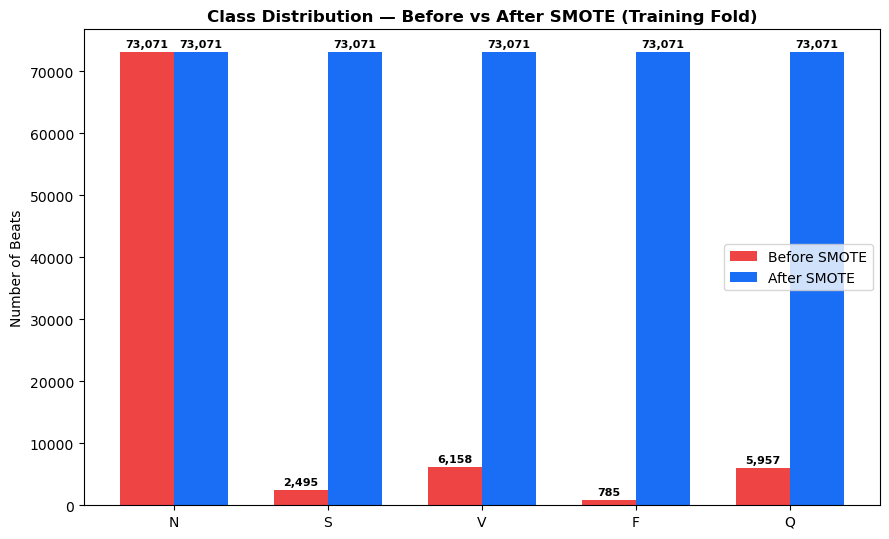

In [26]:
classes = ['N', 'S', 'V', 'F', 'Q']

before_counts = pd.Series(y_train).value_counts()
after_counts = pd.Series(y_train_balanced_labels).value_counts()

before_vals = [before_counts.get(c, 0) for c in classes]
after_vals = [after_counts.get(c, 0) for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width/2, before_vals, width, label='Before SMOTE', color='#ef4444')
bars2 = ax.bar(x + width/2, after_vals, width, label='After SMOTE', color='#1a6ef5')

ax.set_title('Class Distribution — Before vs After SMOTE (Training Fold)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Beats')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 800, f'{h:,}',
             ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 800, f'{h:,}',
             ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('smote_before_after.png', dpi=150)
plt.show()

## PHASE 4 : Architecture Implementation & Tuning

### MLP Baseline (engineered features + SMOTE)

#### The MLP takes a flat feature vector, not a raw waveform. Your input dimension is 12 (5 time + 2 frequency + 5 wavelet features).
#### Architecture: input(12) → Dense(64, relu) → Dropout → Dense(32, relu) → Dense(5, softmax).
#### Train on X_train_balanced / y_train_balanced (the SMOTE output), evaluate on the untouched test fold. Never apply SMOTE to the test set.

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# Scale features (important for MLP convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(feature_df.iloc[test_idx])

# Encode test labels with the SAME encoder used for training
y_test_encoded = le.transform(y_test)

# Build MLP
mlp = models.Sequential([
    layers.Input(shape=(12,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(5, activation='softmax')
])
mlp.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

history_mlp = mlp.fit(
    X_train_scaled, y_train_balanced,
    validation_split=0.1,
    epochs=30, batch_size=128, verbose=1
)

test_loss, test_acc = mlp.evaluate(X_test_scaled, y_test_encoded)
print(f"MLP test accuracy: {test_acc:.4f}")

Epoch 1/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8043 - loss: 0.5354 - val_accuracy: 0.8532 - val_loss: 0.4020
Epoch 2/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8656 - loss: 0.3729 - val_accuracy: 0.8804 - val_loss: 0.3358
Epoch 3/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8806 - loss: 0.3337 - val_accuracy: 0.8958 - val_loss: 0.2812
Epoch 4/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8872 - loss: 0.3146 - val_accuracy: 0.8953 - val_loss: 0.2844
Epoch 5/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8917 - loss: 0.3028 - val_accuracy: 0.9095 - val_loss: 0.2705
Epoch 6/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8945 - loss: 0.2936 - val_accuracy: 0.9176 - val_loss: 0.2439
Epoch 7/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8968 - loss: 0.2874 - val_accuracy: 0.9214 - val_loss: 0.2408
Epoch 8/30
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8980 - loss: 0

### 1D-CNN (raw beats + class weights)

##### Input is the raw beat: shape (234, 1) — 234 time steps, 1 channel.

##### Conv1D layers slide filters across the waveform to detect QRS-scale patterns. Then pooling reduces length, and dense layers classify.

##### Class weights: compute from the ORIGINAL imbalanced training labels (not SMOTE'd) and pass to model.fit(class_weight=...). This is the sequence-model alternative to SMOTE.

In [28]:
from sklearn.utils.class_weight import compute_class_weight

# Reshape raw beats for Conv1D: (samples, 234, 1)
X_train_seq = beats[train_idx][..., np.newaxis]
X_test_seq = beats[test_idx][..., np.newaxis]
y_train_seq = le.transform(y_train)   # original labels, NOT smote'd
y_test_seq = le.transform(y_test)

# Class weights from the imbalanced training distribution
weights = compute_class_weight('balanced',
                               classes=np.unique(y_train_seq),
                               y=y_train_seq)
class_weight = dict(enumerate(weights))
print("Class weights:", class_weight)

cnn = models.Sequential([
    layers.Input(shape=(234, 1)),
    layers.Conv1D(32, kernel_size=7, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

history_cnn = cnn.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=30, batch_size=128,
    class_weight=class_weight, verbose=1
)
print(f"CNN test accuracy: {cnn.evaluate(X_test_seq, y_test_seq)[1]:.4f}")

Class weights: {0: np.float64(22.539108280254776), 1: np.float64(0.2421370995333306), 2: np.float64(2.9701527614571095), 3: np.float64(7.091462925851704), 4: np.float64(2.8732055862292953)}
Epoch 1/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.7969 - loss: 0.4817 - val_accuracy: 0.7867 - val_loss: 0.7282
Epoch 2/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8656 - loss: 0.2935 - val_accuracy: 0.7612 - val_loss: 0.7387
Epoch 3/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.8939 - loss: 0.2402 - val_accuracy: 0.3769 - val_loss: 1.4308
Epoch 4/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9044 - loss: 0.2002 - val_accuracy: 0.6372 - val_loss: 1.0046
Epoch 5/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9174 - loss: 0.1834 - val_accuracy: 0.6078 - val_loss: 1.0103
Epoch 6/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9195 - loss: 0.1641 - val_accuracy: 0.6421 - val_loss: 1.1074
Epoch 7/30
623/623 ━━━━━━━━━━━

### LSTM (raw beats + class weights)

#### Input shape (234, 1) — same as CNN. The LSTM processes the 234 samples in order, maintaining a hidden state that captures how the signal evolves through the beat.

#### LSTMs are slower to train than CNNs. Start with a single LSTM layer (64 units); only stack a second if underfitting. Keep the same class_weight approach so the three-way comparison is fair.

In [29]:
lstm = models.Sequential([
    layers.Input(shape=(234, 1)),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(5, activation='softmax')
])
lstm.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

history_lstm = lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=30, batch_size=128,
    class_weight=class_weight, verbose=1
)
print(f"LSTM test accuracy: {lstm.evaluate(X_test_seq, y_test_seq)[1]:.4f}")

Epoch 1/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 153s 241ms/step - accuracy: 0.3691 - loss: 1.0803 - val_accuracy: 0.4773 - val_loss: 1.3858
Epoch 2/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 138s 222ms/step - accuracy: 0.6474 - loss: 0.7934 - val_accuracy: 0.4398 - val_loss: 1.3665
Epoch 3/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 145s 227ms/step - accuracy: 0.6716 - loss: 0.8647 - val_accuracy: 0.4606 - val_loss: 1.5319
Epoch 4/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 144s 231ms/step - accuracy: 0.6961 - loss: 0.7442 - val_accuracy: 0.5899 - val_loss: 1.2402
Epoch 5/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 203s 232ms/step - accuracy: 0.7508 - loss: 0.6581 - val_accuracy: 0.5007 - val_loss: 1.3908
Epoch 6/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 148s 237ms/step - accuracy: 0.7780 - loss: 0.6107 - val_accuracy: 0.5386 - val_loss: 1.4656
Epoch 7/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 201s 236ms/step - accuracy: 0.8140 - loss: 0.5627 - val_accuracy: 0.5896 - val_loss: 1.3701
Epoch 8/30
623/623 ━━━━━━━━━━━━━━━━━━━━ 150s 241ms/step - accuracy: 0.7872 -

## PHASE 5 : Comparative Evaluation

### Per-Class Metrics & Confusion Matrices

#### sklearn's classification_report gives per-class precision, recall, and F1 in one call. The confusion matrix shows exactly which classes get confused with which.

#### Watch especially for: S predicted as N (a known hard case), and F (fusion) recall — F is your rarest class at 785 training beats, so it's the toughest test of whether imbalance handling worked.

656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

===== MLP =====
              precision    recall  f1-score   support

           F      0.000     0.000     0.000        17
           N      0.926     0.745     0.826     17524
           Q      0.550     0.669     0.604      2084
           S      0.020     0.042     0.027       286
           V      0.250     0.770     0.377      1077

    accuracy                          0.729     20988
   macro avg      0.349     0.445     0.367     20988
weighted avg      0.841     0.729     0.769     20988



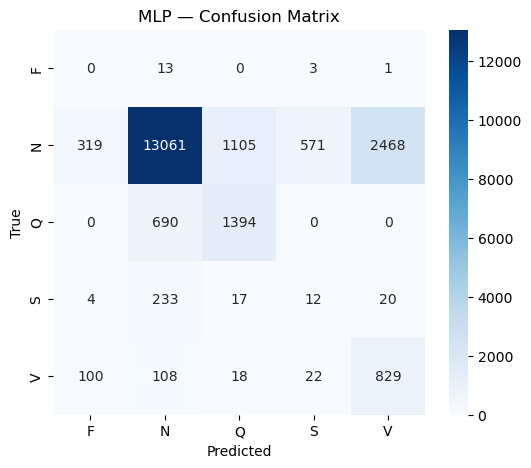

656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

===== CNN =====
              precision    recall  f1-score   support

           F      0.000     0.000     0.000        17
           N      0.979     0.636     0.771     17524
           Q      0.734     0.956     0.830      2084
           S      0.152     0.241     0.186       286
           V      0.150     0.894     0.257      1077

    accuracy                          0.675     20988
   macro avg      0.403     0.546     0.409     20988
weighted avg      0.900     0.675     0.742     20988



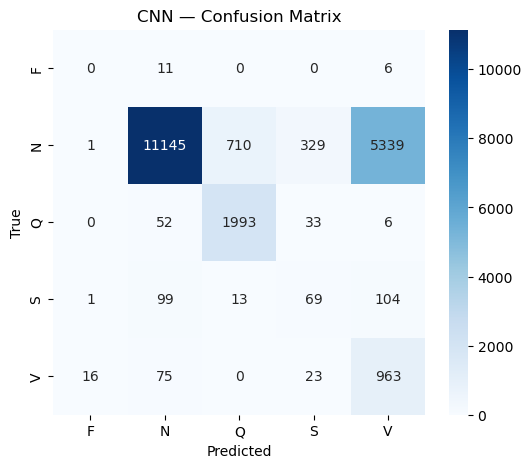

656/656 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step

===== LSTM =====
              precision    recall  f1-score   support

           F      0.000     0.000     0.000        17
           N      0.842     0.387     0.530     17524
           Q      0.249     0.490     0.330      2084
           S      0.009     0.126     0.016       286
           V      0.161     0.690     0.261      1077

    accuracy                          0.409     20988
   macro avg      0.252     0.339     0.228     20988
weighted avg      0.736     0.409     0.489     20988



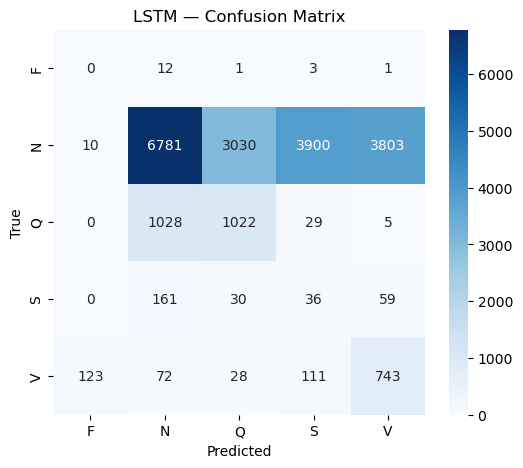

In [34]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

labels = list(le.classes_)

for name, model, X_eval, y_eval in [
    ('MLP', mlp, X_test_scaled, y_test_encoded),
    ('CNN', cnn, X_test_seq, y_test_seq),
    ('LSTM', lstm, X_test_seq, y_test_seq)
]:
    y_pred = np.argmax(model.predict(X_eval), axis=1)
    print(f"\n===== {name} =====")
    print(classification_report(y_eval, y_pred, target_names=labels, digits=3))

    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.savefig(f'cm_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Head-to-Head Comparison Table & Plot

#### Use MACRO-averaged F1 (unweighted mean across classes) as your headline metric, not accuracy or weighted-F1 — macro-F1 treats every class equally, so it rewards models that handle the rare arrhythmias well.

#### Collect the three models' macro-F1 (and per-class F1) into one dataframe and plot side by side. This is the figure your supervisor and examiner will look at first.

656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
656/656 ━━━━━━━━━━━━━━━━━━━━ 31s 47ms/step
        F      N      Q      S      V  MACRO-F1
MLP   0.0  0.826  0.604  0.027  0.377     0.367
CNN   0.0  0.771  0.830  0.186  0.257     0.409
LSTM  0.0  0.530  0.330  0.016  0.261     0.228


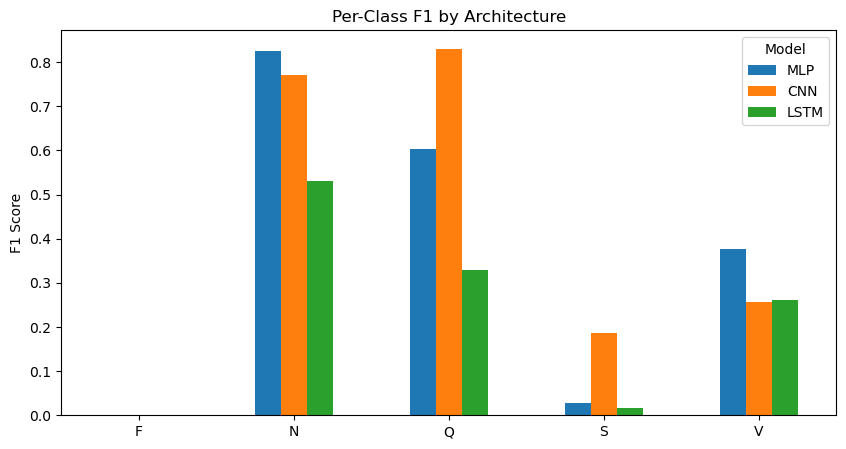

In [35]:
from sklearn.metrics import f1_score

results = {}
for name, model, X_eval, y_eval in [
    ('MLP', mlp, X_test_scaled, y_test_encoded),
    ('CNN', cnn, X_test_seq, y_test_seq),
    ('LSTM', lstm, X_test_seq, y_test_seq)
]:
    y_pred = np.argmax(model.predict(X_eval), axis=1)
    per_class = f1_score(y_eval, y_pred, average=None)
    macro = f1_score(y_eval, y_pred, average='macro')
    results[name] = list(per_class) + [macro]

class_names = list(le.classes_)
comparison = pd.DataFrame(results, index=class_names + ['MACRO-F1']).T
print(comparison.round(3))

comparison[class_names].T.plot(kind='bar', figsize=(10,5))
plt.title('Per-Class F1 by Architecture')
plt.ylabel('F1 Score'); plt.xticks(rotation=0)
plt.legend(title='Model')
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## PHASE 6 : Error Analysis & Interpretation

### Misclassification Pattern Analysis

#### Look at the off-diagonal cells in your confusion matrices. The common findings in MIT-BIH work:

##### • S ↔ N confusion: supraventricular beats can look almost normal — hardest distinction.
##### • F ↔ V confusion: fusion beats are literally part-ventricular, so overlap is expected.
##### • Q usually easiest: paced beats have a distinctive morphology.

#### Pull actual example waveforms of misclassified beats to show WHY — a misclassified S that visually resembles an N is far more convincing evidence than a number.

656/656 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
Confusion matrix (rows = true, cols = predicted):
        pred_F  pred_N  pred_Q  pred_S  pred_V
true_F       0      11       0       0       6
true_N       1   11145     710     329    5339
true_Q       0      52    1993      33       6
true_S       1      99      13      69     104
true_V      16      75       0      23     963 

Row-normalised (fraction of each true class sent to each prediction):
        pred_F  pred_N  pred_Q  pred_S  pred_V
true_F   0.000   0.647   0.000   0.000   0.353
true_N   0.000   0.636   0.041   0.019   0.305
true_Q   0.000   0.025   0.956   0.016   0.003
true_S   0.003   0.346   0.045   0.241   0.364
true_V   0.015   0.070   0.000   0.021   0.894 

Dominant misclassification per true class:
  true F (n=   17):  0.0% correct | most confused with N (64.7%)
  true N (n=17524): 63.6% correct | most confused with V (30.5%)
  true Q (n= 2084): 95.6% correct | most confused with N (2.5%)
  true S (n=  286): 24.1% correct 

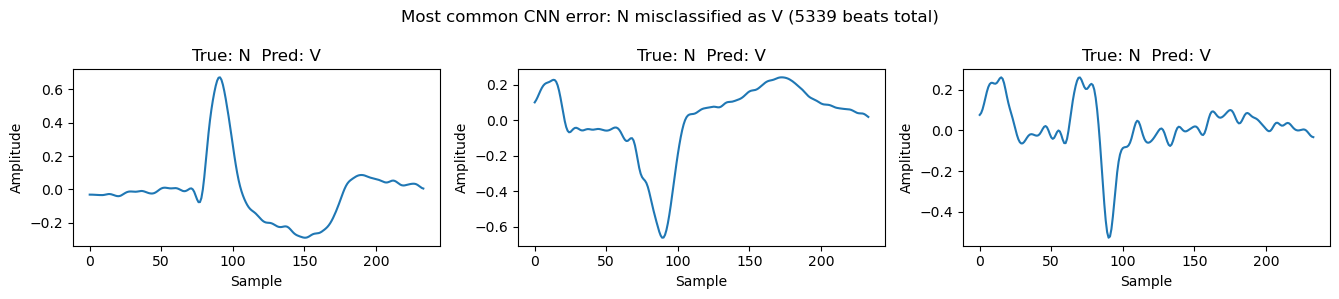

In [41]:
# ── Phase 6: Confusion-matrix-driven error analysis (best model = CNN by macro-F1) ──
from sklearn.metrics import confusion_matrix

class_names = list(le.classes_)                       # ['F','N','Q','S','V']
n_classes = len(class_names)

y_pred_cnn = np.argmax(cnn.predict(X_test_seq), axis=1)

# Rows = TRUE class, cols = PREDICTED class
cm = confusion_matrix(y_test_seq, y_pred_cnn, labels=range(n_classes))
cm_df = pd.DataFrame(cm, index=[f'true_{c}' for c in class_names],
                         columns=[f'pred_{c}' for c in class_names])

# Row-normalise: where does each true class's beats actually go?
cm_row_norm = cm_df.div(cm_df.sum(axis=1).replace(0, np.nan), axis=0).round(3)

print("Confusion matrix (rows = true, cols = predicted):")
print(cm_df, "\n")
print("Row-normalised (fraction of each true class sent to each prediction):")
print(cm_row_norm, "\n")

# Dominant error per true class, extracted programmatically
print("Dominant misclassification per true class:")
for t in range(n_classes):
    total = cm[t].sum()
    if total == 0:
        print(f"  {class_names[t]}: no beats in test set")
        continue
    off = cm[t].copy(); off[t] = 0                     # zero the diagonal
    top = int(np.argmax(off))
    print(f"  true {class_names[t]} (n={total:>5}): "
          f"{cm[t][t]/total:5.1%} correct | most confused with "
          f"{class_names[top]} ({off[top]/total:.1%})")

# Single largest off-diagonal error, found from the data itself
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
t_idx, p_idx = np.unravel_index(np.argmax(cm_off), cm_off.shape)
true_lbl, pred_lbl = class_names[t_idx], class_names[p_idx]
print(f"\nLargest single error type: true {true_lbl} predicted as {pred_lbl} "
      f"({cm_off[t_idx, p_idx]} beats)")

# Plot examples of THAT actual error (never blank axes)
examples = np.where((y_test_seq == t_idx) & (y_pred_cnn == p_idx))[0]
n_show = min(3, len(examples))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(4.5 * n_show, 3), squeeze=False)
    for ax, idx in zip(axes[0], examples[:n_show]):
        ax.plot(beats[test_idx][idx])
        ax.set_title(f'True: {true_lbl}  Pred: {pred_lbl}')
        ax.set_xlabel('Sample'); ax.set_ylabel('Amplitude')
    plt.suptitle(f'Most common CNN error: {true_lbl} misclassified as {pred_lbl} '
                 f'({len(examples)} beats total)')
    plt.tight_layout()
    plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No examples of that error type to plot.")

### Did Imbalance Handling Actually Help?

#### Run a quick ablation: train the MLP once WITHOUT SMOTE (on the raw imbalanced features) and compare its minority-class recall against your SMOTE version.
#### If SMOTE lifted F/S recall substantially while barely touching N, that's direct evidence answering your research question "How does SMOTE affect minority-class recognition?" — a concrete, defensible finding rather than an assumption.

In [37]:
# Ablation: MLP without SMOTE, same architecture
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler

# Dedicated scaler — do NOT refit the global `scaler` (that one belongs to the SMOTE model)
scaler_ns = StandardScaler()
X_train_raw = scaler_ns.fit_transform(feature_df.iloc[train_idx])   # fit on the raw train fold
X_test_raw  = scaler_ns.transform(feature_df.iloc[test_idx])        # test scaled in the SAME space
y_train_raw = le.transform(y_train)

mlp_nosmote = models.Sequential([
    layers.Input(shape=(12,)),
    layers.Dense(64, activation='relu'), layers.Dropout(0.3),
    layers.Dense(32, activation='relu'), layers.Dropout(0.2),
    layers.Dense(5, activation='softmax')
])
mlp_nosmote.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
mlp_nosmote.fit(X_train_raw, y_train_raw, epochs=30,
                batch_size=128, verbose=0)

# Each model is evaluated in the feature space it was trained in:
#   mlp_nosmote -> X_test_raw    (raw-fit scaler)
#   mlp (SMOTE) -> X_test_scaled (SMOTE-fit scaler, from the SMOTE MLP cell)
y_pred_ns = np.argmax(mlp_nosmote.predict(X_test_raw),  axis=1)
y_pred_s  = np.argmax(mlp.predict(X_test_scaled),       axis=1)

rec_ns = recall_score(y_test_encoded, y_pred_ns, average=None)
rec_s  = recall_score(y_test_encoded, y_pred_s,  average=None)

comp = pd.DataFrame({'Without SMOTE': rec_ns, 'With SMOTE': rec_s},
                    index=list(le.classes_))   # ['F','N','Q','S','V'] — matches encoded order
print("Per-class RECALL comparison (inter-patient test set):")
print(comp.round(3))

656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Per-class RECALL comparison (inter-patient test set):
   Without SMOTE  With SMOTE
F          0.000       0.000
N          0.785       0.745
Q          0.008       0.669
S          0.000       0.042
V          0.631       0.770
